In [ ]:
# ============================================================
# INSTALASI (jalankan sekali di terminal/Colab)
!pip install bertopic sentence-transformers umap-learn hdbscan
!pip install Sastrawi  # stopwords Bahasa Indonesia
# ============================================================

import re
import warnings
warnings.filterwarnings("ignore")

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import pandas as pd

# ============================================================
# 1. DATA JAWABAN KUESIONER
# ============================================================

jawaban_q1 = [
    "sering kebablasan kalau udah membuka aplikasi tersebut",
    "Jika tidak membuka salah satu media sosial terasa ada yang kurang dalam hidup.",
    "Tidak saya cendrung ke youtube",
    "Karena ketiga media sosial itu jarang saya gunakan sebenarnya tidak terlalu mempengaruhi fokus (kecuali tiktok) dan terkadang juga efeknya untuk mempengaruhi produktivitas belajar",
    "Tidak terlalu mempengaruhi secara langsung",
    "fokus belajar saya sedikit terganggu karena ingin scroll reels",
    "Tidak ada",
    "Lengah dikit scroll gajadi belajar padahal buka laptop.",
    "Sedikit cerita, ketika saya sedang semangat-semangatnya mengerjakan tugas dan by hp, ketika saya ingin melihat catatan yang ada di papan tulis lewat whatsapp saya kadang terdistraksi malah membuka instagram dan berakibat scroll reels berjam-jam, alhasil tugas jadi tidak dikerjakan dan ditunda sehingga hasil pengerjaan saya tidak maksimal",
    "Sangat memengaruhi karena mudah terdistrack atau terganggu, sehingga kalau belajar jangan sampai buka sosial media",
    "Terkadang mengganggu produktivitas",
    "Belajar dan mengerjakan tugas jadi sering terganggu karena pengennya scroll terus",
    "penggunaan medsos tersebut menggangu fokus saya saat belajar",
    "sebenarnya penggunaan ketiga platform media sosial tersebut malah mengurangi waktu produktivitas dan fokus untuk belajar, dan sekarang penggunaan media sosial saya gunakan jika saat beristirahat dari kegiatan produktivitas agar tidak mengurangi fokus",
    "Honestly, it does affect my focus and productivity, but not in a completely bad way. X kadang malah bantu aku dapet new insights dari berbagai pembahasan. Kalau instagram, aku jarang bgt buka kecuali lagi pengen upload, jadi almost no effect. Yang paling ngaruh itu TikTok cuz once i start scrolling, it's easy to lose track of time.",
    "Sangat berpengaruh, kadang jadi lupa waktu.",
    "Membuat saya lebih santai setelah menjalani kehidupan yang melelahkan",
    "semakin lama menggunakan media sosial membuat saya semakin kehilangan fokus",
    "Sebagai media informasi dan salah satu sumber pengetahuan",
    "tidak, semua ada waktunya",
    "dari ketiga media sosial tersebut paling sering menggunakan instagram karena sudah terbiasa dan otomatis pikiran langsung mengarah ke sana, hal tersebut sangat memengaruhi fokus belajar saya ketika membuka hp",
    "Saya pribadi mudah terdistract pada notif sosmed, yang mempengaruhi fokus dalam mengerjakan tugas atau belajar saya",
    "-",
    "Instagram membuat saya kurang produktif",
    "Menurutku sih media sosial itu ngaruh ke fokus belajar. Kadang niatnya cuma mau buka sebentar buat refreshing, tapi malah jadi keterusan scroll. Walau kadang bisa dapet info yang penting dari media sosial itu sih",
    "menggunakan media sosial ketika sedang refreshing saja, ketika belajar sangat disarankan hp nya dijauhin dlu biar ga ke distrack pengen buka hp trs",
    "Penggunaan media sosial terkadang membuat saya malas mengerjakan tugas.",
    "Mendistraksi pol",
    "Lumayan mempengaruhi, apalagi kalau sudah terlalu asik scroll dan ada tugas pasti tertunda",
    "biasa aja",
    "Saya terkadang kebawa arus ketika bermain tiktok",
    "kadang membuat produktivitas belajar menurun, tetapi juga bisa membuat saya terhibur jika stress dengan tugas kuliah",
    "lebih sering scroll meme untuk hiburan di instagram",
    "Aku biasanya pakai Instagram dan TikTok masing-masing sekitar 120 menit sehari, dan itu lumayan ngaruh ke fokus belajar. Awalnya cuma buka bentar pas istirahat, tapi sering keterusan scrolling lama banget.",
    "Sangat berpengaruh saat gabut",
    "Menurut saya karna sudah terlalu nyaman dengan penggunaan media sosial sangat susah untuk berhenti apalagi fokus pada produktivitas lainnya",
    "tiktok bikin lupa waktu",
    "utamanya tiktok dan reels ig dengan algoritma scrolling tanpa hentinya sering membuat saya lupa kehidupan nyata. masalah produktivitas tetap bisa fokus",
    "menurut saya, kebiasaan penggunaan media sosial diatas dapat mempengaruhi sistem pembelajaran... yaah, karna terkadang fokus bisa ambyar/buyar dikarenakan terlena akan scroll medsos diatas",
    "mempengaruhi soalnya kadang kalau niat mau belajar trs ngga sengaja mbukak tiktok atau ig itu jdi kelamaan diaplikasi tersebut jdi fokus belajarnya terganggu",
    "Hanya untuk bahan refreshing dikala Burnout, namun masalahnya terkadang kebablasan",
    "Saat mau mengerjakan tugas atau belajar materi tiba-tiba buka medsos, apalagi kalau matkul yang ada matematikanya.",
    "kalau bosan lihat Ig, kalau X kadang-kadang cuman untuk ikut nimbrung dengan apa yang sedang trending",
    "Sebenarnya tidak terlalu berpengaruh",
    "Sebenernya, hobi scrolling TikTok dan Instagram itu jadi penghambat besar buat aku. Sering banget niatnya cuma mau lihat sebentar, tapi malah kebablasan sampai berjam-jam. Ujung-ujungnya jadi mager parah dan nggak punya tenaga lagi buat sekadar buka buku atau nyicil tugas.",
    "beberapa bisa digunakan untuk belajar, tapi terkadang lengah akhirnya scroll dan lupa dengan tugas yang akan dikerjakan",
    "kadang kalau udh kelamaan jadi males itu yg paling mengganggu",
    "Biasa saja",
    "Jujur saja, cukup mengganggu waktu belajar/fokus sehari-hari sih. Sering niatnya cuma mau buka sebentar buat refreshing atau sekadar cek notifikasi, tapi malah sering kebablasan sampai lupa waktu.",
    "Meskipun saya hanya mengakses media sosial setelah kegiatan belajar selesai, kebiasaan ini tetap cukup mengganggu produktivitas karena sering kali waktu istirahat singkat berubah menjadi durasi scrolling yang panjang—terutama pada TikTok—sehingga menggeser jadwal belajar yang sudah saya rencanakan.",
    "Pada saat tertentu ketiga medsos tersebut menjadi distraksi yang serius dalam produktivitas belajar",
    "lupa waktu",
    "Kebiasaan penggunaan media sosial tersebut kadang mempengaruhi aktivitas belajar, kegiatan belajar berkurang karena terlalu lama menggunakan medsos tersebut",
    "Instagram sangat kuat memengaruhi fokus saya dalam belajar dibandingkan dengan media sosial lainnya.",
    "Scroll reels Instagram terkadang mendistrak ketika berniat ingin belajar",
]

jawaban_q2 = [
    "tiktok, setiap membukanya pasti kecanduan untuk lihat konten-kontennya",
    "Instagram, banyak memberikan informasi terbaru tentang berita.",
    "Instagram, karena menghibur",
    "TikTok, karena algoritma nya sangat paham apa yang ingin dilihat terutama pada generasi muda.",
    "Instagram, platform Instagram lebih mudah digunakan dan kontennya lebih relevan dengan yang saya inginkan.",
    "Instagram, menarik",
    "Ntahlah",
    "Tiktok dan ig reels karena tidak ada habisnya.",
    "TikTok, karena di aplikasi TikTok itu algoritma nya sangat mudah, tinggal scroll konten, namun disisi lain ada penelitian jika otak kita sering mengkonsumsi konten pendek maka otak kita akan mengalami kebusukan atau brainroot",
    "Tiktok, karena kontennya lucu lucu dan bikin ketagihan",
    "Tiktok, karena banyaknya konten",
    "Tiktok, karena konten yg lewat menarik",
    "tiktok",
    "tiktok, karena saya jarang menggunakan instagram dan lebih banyak penggunaan tiktok, saya rasa tiktok lebih update mengenai berita/tren sekarang",
    "I choose X cuz its the most addictive and hardest to leave. The main reason is karena algoritmanya bener-bener tailored ke kita. A lot of good information from various topics.",
    "Reels ig",
    "Gaada semuanya bisa ditinggal kalau ada kerjaan",
    "tiktok karena isinya random jadinya menarik",
    "Instagram, algoritmanya oke, pengguna lama juga",
    "Tiktok, komentarnya lucu-lucu bikin ketawa",
    "Menurut saya instagram karena saya paling lama buka instagram",
    "Tiktok, karena konten yang diberikan selalu asik dan sesuai minat/favorit",
    "X",
    "Instagram, karena reels-nya asik-asik",
    "Menurutku instagram sama tiktok, soalnya isinya berupa video pendek gitu jadi keterusan scroll",
    "Tiktok, karena lebih nyaman cari info disitu",
    "TikTok",
    "Karena lebih menarik",
    "Tiktok, video lucu, video kucing, berita yang lagi panas",
    "Tiktok, karena algoritmanya sesuai dengan apa yang saya sukai",
    "x",
    "Tiktok karena sudah terbiasa bermain tiktok, di ig hanya menonton story orang lain dan upload sedikit sedikit",
    "Tik tok, karena update terus",
    "instagram karena penggunaannya praktis",
    "Dari ketiganya, menurutku TikTok paling adiktif dan susah ditinggalin. Soalnya videonya pendek-pendek tapi terus nyambung, dan algoritmanya kayak ngerti banget apa yang kita suka.",
    "Tiktok, berisi informasi yg cepat berubah",
    "Tiktok, karna banyaknya konten menarik",
    "tiktok",
    "tiktok, personalisasi algoritma terbaik",
    "tiktok sih, karna menurut saya media tersebut lebih relevan/gampang digunakan buat update informasi, ketimbang medsos lainnya",
    "menurut saya X si soalnya saya tidak pernah memakai medsos tersebut jdinya kurang tau",
    "Instagram, reels nya bagus bagus dan cakupannya lebih luas untuk dipilih waktu di beranda dibandingkan TikTok",
    "Instagram, karena rekomendasi kontennya yang sering sesuai dengan minat jadi tanpa sadar scroll lama",
    "Instagram",
    "Tiktok, karena instagram dan x tidak membuat saya tertarik",
    "tik tok, alasannya karena banyak konten yg menghibur, apalagi pas buka komen asbun",
    "tiktok & ig karena banyak info update yang tampilannya enak diliat dan gampang dicari",
    "tiktok, seru aja",
    "Tiktok",
    "Karna banyak konten editan fanbase kpop di tiktok yang seru untuk ditonton, dan pencariannya lebih mudah daripada di Instagram",
    "TikTok, karena TikTok itu adiktif banget kita nggak perlu repot milih tontonan semuanya otomatis dan pas banget sama selera.",
    "TikTok yang paling adiktif menurut saya, karena algoritmanya selalu memberikan konten yang sesuai dengan kesukaan/selera dari usernya.",
    "Tiktok",
    "tiktok, videonya menarik",
    "TikTok, karena berbagai konten ada disana jadi untuk ditinggalkan lumayan susah, karena faktor kebiasaan juga",
    "Instagram, karena saya hanya sering menggunakan Instagram dibandingkan media sosial yang lain.",
    "Instagram, sangat relate dan beragam",
]

# ============================================================
# 2. PREPROCESSING — FILTER JAWABAN TIDAK VALID
# ============================================================

def is_valid(text):
    text = text.strip()
    if len(text) < 10:
        return False
    if text in ["-", ".", "Ntahlah", "biasa aja", "Biasa saja", "lupa waktu", "Mendistraksi pol"]:
        return False
    return True

docs_q1 = [t for t in jawaban_q1 if is_valid(t)]
docs_q2 = [t for t in jawaban_q2 if is_valid(t)]

print(f"Q1 valid: {len(docs_q1)} dokumen")
print(f"Q2 valid: {len(docs_q2)} dokumen")

# ============================================================
# 3. SETUP KOMPONEN BERTOPIC
# ============================================================

# IndoSBERT — embedding model Bahasa Indonesia
embedding_model = SentenceTransformer("firqaaa/indo-sentence-bert-base")

# UMAP — reduksi dimensi (n_neighbors kecil karena dataset kecil)
umap_model = UMAP(
    n_neighbors=5,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# HDBSCAN — clustering density-based
hdbscan_model = HDBSCAN(
    min_cluster_size=3,
    min_samples=2,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# Stopwords Bahasa Indonesia via Sastrawi
factory = StopWordRemoverFactory()
stop_words_id = factory.get_stop_words()
# Tambah stopword custom
extra_stopwords = ["yg", "nya", "aja", "sih", "deh", "karna", "karena",
                   "udah", "udh", "jadi", "jd", "itu", "ini", "buat",
                   "bisa", "kalo", "kalau", "sama", "juga", "lebih",
                   "banget", "bgt", "kita", "saya", "aku", "tapi",
                   "atau", "dan", "ke", "di", "yang", "dengan", "dari",
                   "ga", "gak", "tidak", "nggak", "ngga", "gajadi",
                   "kecuali", "memang", "malah", "sudah", "sdh",
                   "setelah", "sebelum", "antara", "tentang", "dlu"]
all_stopwords = list(set(stop_words_id + extra_stopwords))

vectorizer_model = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1, 2),
    min_df=1
)

# ============================================================
# 4. FUNGSI RUN BERTOPIC
# ============================================================

def run_bertopic(docs, pertanyaan_label):
    print(f"\n{'='*60}")
    print(f"📊 BERTOPIC — {pertanyaan_label}")
    print(f"{'='*60}")

    model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        top_n_words=8,
        nr_topics="auto",
        calculate_probabilities=True,
        verbose=False
    )

    topics, probs = model.fit_transform(docs)

    # Info tiap topik
    topic_info = model.get_topic_info()
    print(f"\n🔢 Jumlah topik ditemukan: {len(topic_info[topic_info['Topic'] != -1])}")
    print(f"📌 Dokumen tidak terklasifikasi (outlier): {sum(1 for t in topics if t == -1)}")

    print("\n📋 RINGKASAN TOPIK:\n")
    for _, row in topic_info.iterrows():
        if row["Topic"] == -1:
            label = "[-1] OUTLIER"
        else:
            label = f"[Topik {row['Topic']}]"
        print(f"  {label} | Jumlah dok: {row['Count']} | Nama: {row['Name']}")

    print("\n🔑 KATA KUNCI PER TOPIK (c-TF-IDF):\n")
    for topic_id in sorted(set(topics)):
        if topic_id == -1:
            continue
        words = model.get_topic(topic_id)
        keywords = ", ".join([w for w, _ in words])
        print(f"  Topik {topic_id}: {keywords}")

    print("\n📄 DISTRIBUSI JAWABAN KE TOPIK:\n")
    doc_info = model.get_document_info(docs)
    for i, row in doc_info.iterrows():
        topik = row["Topic"]
        nama = row["Name"] if topik != -1 else "OUTLIER"
        print(f"  [{topik}] {row['Document'][:80]}...")

    return model, topics, probs

# ============================================================
# 5. JALANKAN UNTUK KEDUA PERTANYAAN
# ============================================================

model_q1, topics_q1, probs_q1 = run_bertopic(docs_q1, "Q1 — Pengaruh Medsos terhadap Fokus Belajar")
model_q2, topics_q2, probs_q2 = run_bertopic(docs_q2, "Q2 — Platform Paling Adiktif")

# ============================================================
# 6. SIMPAN HASIL KE CSV
# ============================================================

result_q1 = model_q1.get_document_info(docs_q1)[["Document", "Topic", "Name", "Probability"]]
result_q1.columns = ["Jawaban", "Topik", "Nama_Topik", "Probabilitas"]
result_q1.to_csv("hasil_topik_q1.csv", index=False, encoding="utf-8-sig")

result_q2 = model_q2.get_document_info(docs_q2)[["Document", "Topic", "Name", "Probability"]]
result_q2.columns = ["Jawaban", "Topik", "Nama_Topik", "Probabilitas"]
result_q2.to_csv("hasil_topik_q2.csv", index=False, encoding="utf-8-sig")

print("\n✅ Hasil disimpan ke: hasil_topik_q1.csv dan hasil_topik_q2.csv")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.5 MB/s eta 0:00:00
Q1 valid: 49 dokumen
Q2 valid: 47 dokumen


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/118 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


📊 BERTOPIC — Q1 — Pengaruh Medsos terhadap Fokus Belajar

🔢 Jumlah topik ditemukan: 4
📌 Dokumen tidak terklasifikasi (outlier): 0

📋 RINGKASAN TOPIK:

  [Topik 0] | Jumlah dok: 23 | Nama: 0_buka_tugas_tiktok_belajar
  [Topik 1] | Jumlah dok: 14 | Nama: 1_media_sosial_produktivitas_media sosial
  [Topik 2] | Jumlah dok: 8 | Nama: 2_fokus_media sosial_sosial_media
  [Topik 3] | Jumlah dok: 4 | Nama: 3_scroll_scroll reels_reels_instagram

🔑 KATA KUNCI PER TOPIK (c-TF-IDF):

  Topik 0: buka, tugas, tiktok, belajar, sering, kebablasan, scroll, kadang
  Topik 1: media, sosial, produktivitas, media sosial, belajar, fokus, penggunaan, penggunaan media
  Topik 2: fokus, media sosial, sosial, media, membuat, fokus belajar, tersebut, instagram
  Topik 3: scroll, scroll reels, reels, instagram, kadang, berniat belajar, belajar sedikit, berniat

📄 DISTRIBUSI JAWABAN KE TOPIK:

  [0] sering kebablasan kalau udah membuka aplikasi tersebut...
  [1] Jika tidak membuka salah satu media sosial terasa ad

In [ ]:
# Tambahkan di akhir kode setelah fit_transform

# Penamaan manual Q1
topic_labels_q1 = {
    0: "Distraksi Aktif saat Belajar (TikTok/Scroll)",
    1: "Dampak Umum Media Sosial terhadap Produktivitas",
    2: "Gangguan Fokus akibat Instagram",
    3: "Kecanduan Reels Pasif"
}

# Penamaan manual Q2
topic_labels_q2 = {
    0: "TikTok Adiktif: Algoritma & Konten Pendek",
    1: "Instagram Adiktif: Kebiasaan & Relevansi Konten",
    2: "Instagram Reels: Daya Tarik Visual"
}

model_q1.set_topic_labels(topic_labels_q1)
model_q2.set_topic_labels(topic_labels_q2)

In [ ]:
model_q2.get_topic_info()

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,0,34,0_tiktok_konten_menarik tiktok_lucu,TikTok Adiktif: Algoritma & Konten Pendek,"[tiktok, konten, menarik tiktok, lucu, menarik...","[tiktok, karena saya jarang menggunakan instag..."
1,1,10,1_instagram_lama_lama instagram_sering,Instagram Adiktif: Kebiasaan & Relevansi Konten,"[instagram, lama, lama instagram, sering, kont...",[Menurut saya instagram karena saya paling lam...
2,2,3,2_reels_bagus_instagram reels_asik,Instagram Reels: Daya Tarik Visual,"[reels, bagus, instagram reels, asik, asik asi...",[Tiktok dan ig reels karena tidak ada habisnya...


In [ ]:
def hitung_diversity(model, label, top_n=10):
    all_words = []
    for t in sorted(set(model.topics_)):
        if t == -1:
            continue
        words = [w for w, _ in model.get_topic(t)[:top_n]]
        all_words.extend(words)

    unique_ratio = len(set(all_words)) / len(all_words) if all_words else 0
    print(f"✅ Topic Diversity {label}: {unique_ratio:.4f}")
    return unique_ratio

div_q1 = hitung_diversity(model_q1, "Q1")
div_q2 = hitung_diversity(model_q2, "Q2")

✅ Topic Diversity Q1: 0.7500
✅ Topic Diversity Q2: 1.0000


In [ ]:
!pip install gensim
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

def hitung_coherence(model, docs, label):
    # Ambil top words per topik
    topics_words = [
        [word for word, _ in model.get_topic(t)]
        for t in sorted(set(model.topics_))
        if t != -1
    ]
    # Tokenisasi sederhana
    tokenized = [doc.lower().split() for doc in docs]
    dictionary = Dictionary(tokenized)

    cm = CoherenceModel(
        topics=topics_words,
        texts=tokenized,
        dictionary=dictionary,
        coherence="c_v"  # c_v paling umum dipakai di jurnal
    )
    score = cm.get_coherence()
    print(f"✅ Topic Coherence (c_v) {label}: {score:.4f}")
    return score

coh_q1 = hitung_coherence(model_q1, docs_q1, "Q1")
coh_q2 = hitung_coherence(model_q2, docs_q2, "Q2")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.0 MB/s eta 0:00:00
✅ Topic Coherence (c_v) Q1: 0.5512
✅ Topic Coherence (c_v) Q2: 0.5959


In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

def hitung_silhouette(embedding_model_st, model, docs, topics, label):
    # Pakai embedding_model SentenceTransformer langsung (bukan dari model.embedding_model)
    embeddings = embedding_model_st.encode(docs, show_progress_bar=False)

    # Transform ke UMAP space — gunakan model UMAP yang sudah fit
    umap_embeddings = model.umap_model.transform(embeddings)

    # Filter outlier topic -1
    indices = [i for i, t in enumerate(topics) if t != -1]
    X = umap_embeddings[np.array(indices)]
    labels = [t for t in topics if t != -1]

    if len(set(labels)) < 2:
        print(f"{label}: Tidak cukup kluster")
        return None

    score = silhouette_score(X, labels, metric="euclidean")
    print(f"✅ Silhouette Score {label}: {score:.4f}")
    return score

# Panggil dengan embedding_model (variabel SentenceTransformer yang kamu buat di awal)
sil_q1 = hitung_silhouette(embedding_model, model_q1, docs_q1, topics_q1, "Q1")
sil_q2 = hitung_silhouette(embedding_model, model_q2, docs_q2, topics_q2, "Q2")

✅ Silhouette Score Q1: -0.1200
✅ Silhouette Score Q2: 0.7918


In [ ]:
from umap import UMAP
from hdbscan import HDBSCAN

# Konfigurasi lebih granular untuk Q1
umap_model_q1 = UMAP(
    n_neighbors=4,      # Lebih kecil = lebih sensitif struktur lokal
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model_q1 = HDBSCAN(
    min_cluster_size=2,  # Turun dari 3 → bisa membentuk kluster lebih kecil
    min_samples=1,       # Turun dari 2
    metric="euclidean",
    cluster_selection_method="leaf",  # Ganti dari "eom" → lebih banyak kluster kecil
    prediction_data=True
)

# Buat ulang model Q1 dengan config baru
model_q1_v2 = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model_q1,
    hdbscan_model=hdbscan_model_q1,
    vectorizer_model=vectorizer_model,
    top_n_words=8,
    nr_topics="auto",
    calculate_probabilities=True,
    verbose=False
)

topics_q1_v2, probs_q1_v2 = model_q1_v2.fit_transform(docs_q1)

# Cek ulang silhouette
sil_q1_v2 = hitung_silhouette(embedding_model, model_q1_v2, docs_q1, topics_q1_v2, "Q1 v2")

✅ Silhouette Score Q1 v2: 0.4993


In [ ]:
from itertools import product

configs = [
    # (n_neighbors, n_components, min_cluster_size, min_samples, method)
    (3, 3, 2, 1, "leaf"),
    (3, 5, 2, 1, "leaf"),
    (4, 3, 2, 1, "leaf"),
    (3, 3, 3, 1, "leaf"),
    (4, 4, 2, 1, "leaf"),
    (5, 3, 2, 1, "leaf"),
    (3, 4, 2, 1, "leaf"),
]

best_score = -999
best_cfg = None

for n_nbr, n_comp, min_cls, min_smp, method in configs:
    try:
        _umap = UMAP(n_neighbors=n_nbr, n_components=n_comp,
                     min_dist=0.0, metric="cosine", random_state=42)
        _hdb  = HDBSCAN(min_cluster_size=min_cls, min_samples=min_smp,
                        metric="euclidean", cluster_selection_method=method,
                        prediction_data=True)
        _model = BERTopic(embedding_model=embedding_model,
                          umap_model=_umap, hdbscan_model=_hdb,
                          vectorizer_model=vectorizer_model,
                          top_n_words=8, nr_topics="auto",
                          calculate_probabilities=True, verbose=False)

        _topics, _ = _model.fit_transform(docs_q1)

        # Skip kalau outlier > 20% atau kluster < 2
        n_outlier = sum(1 for t in _topics if t == -1)
        n_cluster = len(set(t for t in _topics if t != -1))
        if n_outlier / len(docs_q1) > 0.20 or n_cluster < 2:
            print(f"[SKIP] nbr={n_nbr} comp={n_comp} cls={min_cls} smp={min_smp} {method} | outlier={n_outlier} cluster={n_cluster}")
            continue

        score = silhouette_score(
            _model.umap_model.transform(embedding_model.encode(docs_q1, show_progress_bar=False)),
            _topics, metric="euclidean"
        )
        print(f"nbr={n_nbr} comp={n_comp} cls={min_cls} smp={min_smp} {method} | skor={score:.4f} | kluster={n_cluster} | outlier={n_outlier}")

        if score > best_score:
            best_score = score
            best_cfg = (n_nbr, n_comp, min_cls, min_smp, method)
            model_q1_best = _model
            topics_q1_best = _topics

    except Exception as e:
        print(f"ERROR: {e}")

print(f"\n🏆 BEST CONFIG: nbr={best_cfg[0]} comp={best_cfg[1]} cls={best_cfg[2]} smp={best_cfg[3]} {best_cfg[4]}")
print(f"🏆 BEST Silhouette Score Q1: {best_score:.4f}")

nbr=3 comp=3 cls=2 smp=1 leaf | skor=0.4858 | kluster=20 | outlier=3
nbr=3 comp=5 cls=2 smp=1 leaf | skor=0.5504 | kluster=19 | outlier=1
nbr=4 comp=3 cls=2 smp=1 leaf | skor=0.4653 | kluster=17 | outlier=1
nbr=3 comp=3 cls=3 smp=1 leaf | skor=0.6123 | kluster=9 | outlier=2
nbr=4 comp=4 cls=2 smp=1 leaf | skor=0.2168 | kluster=11 | outlier=6
nbr=5 comp=3 cls=2 smp=1 leaf | skor=0.3703 | kluster=15 | outlier=3
nbr=3 comp=4 cls=2 smp=1 leaf | skor=0.2349 | kluster=10 | outlier=2

🏆 BEST CONFIG: nbr=3 comp=3 cls=3 smp=1 leaf
🏆 BEST Silhouette Score Q1: 0.6123


In [ ]:
coh_q1_v2 = hitung_coherence(model_q1_v2, docs_q1, "Q2")

✅ Topic Coherence (c_v) Q2: 0.5919


In [ ]:
q1_v2_info = model_q1_v2.get_topic_info()
q1_v2_info
#

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2,-1_penggunaan media_penggunaan_fokus produktiv...,"[penggunaan media, penggunaan, fokus produktiv...",[Penggunaan media sosial terkadang membuat say...
1,0,5,0_instagram_scrolling_berjam_it,"[instagram, scrolling, berjam, it, jam, masing...","[Sebenernya, hobi scrolling TikTok dan Instagr..."
2,1,4,1_produktivitas_mengurangi_gunakan_fokus,"[produktivitas, mengurangi, gunakan, fokus, se...",[utamanya tiktok dan reels ig dengan algoritma...
3,2,4,2_medsos_diatas_kebiasaan penggunaan_medsos te...,"[medsos, diatas, kebiasaan penggunaan, medsos ...",[Pada saat tertentu ketiga medsos tersebut men...
4,3,3,3_media_sosial_buka sosial_belajar jangan,"[media, sosial, buka sosial, belajar jangan, i...",[Sebagai media informasi dan salah satu sumber...
5,4,3,4_semakin_memengaruhi fokus_memengaruhi_menggu...,"[semakin, memengaruhi fokus, memengaruhi, meng...",[semakin lama menggunakan media sosial membuat...
6,5,3,5_lengah_scroll_akhirnya_beberapa digunakan,"[lengah, scroll, akhirnya, beberapa digunakan,...",[Belajar dan mengerjakan tugas jadi sering ter...
7,6,3,6_berpengaruh_terlalu_gabut sebenarnya_berpeng...,"[berpengaruh, terlalu, gabut sebenarnya, berpe...","[Tidak terlalu mempengaruhi secara langsung, S..."
8,7,2,7_produktif_membuat kurang_youtube instagram_c...,"[produktif, membuat kurang, youtube instagram,...","[Tidak saya cendrung ke youtube, Instagram mem..."
9,8,2,8_hp_aplikasi_belajar sangat_aplikasi tersebut,"[hp, aplikasi, belajar sangat, aplikasi terseb...",[sering kebablasan kalau udah membuka aplikasi...


In [ ]:
from itertools import product
from sklearn.metrics import silhouette_score
import numpy as np

configs = [
    # (n_neighbors, n_components, min_cluster_size, min_samples, method)
    (3, 3, 2, 1, "leaf"),
    (3, 5, 2, 1, "leaf"),
    (4, 3, 2, 1, "leaf"),
    (3, 3, 3, 1, "leaf"),
    (4, 4, 2, 1, "leaf"),
    (5, 3, 2, 1, "leaf"),
    (3, 4, 2, 1, "leaf"),
]

best_score = -999
best_cfg = None
model_q1_best = None
topics_q1_best = None

print("=" * 70)
print("🔍 GRID SEARCH — Optimasi BERTopic Q1")
print("=" * 70)

for n_nbr, n_comp, min_cls, min_smp, method in configs:
    try:
        _umap = UMAP(
            n_neighbors=n_nbr, n_components=n_comp,
            min_dist=0.0, metric="cosine", random_state=42
        )
        _hdb = HDBSCAN(
            min_cluster_size=min_cls, min_samples=min_smp,
            metric="euclidean", cluster_selection_method=method,
            prediction_data=True
        )
        _model = BERTopic(
            embedding_model=embedding_model,
            umap_model=_umap, hdbscan_model=_hdb,
            vectorizer_model=vectorizer_model,
            top_n_words=8, nr_topics="auto",
            calculate_probabilities=True, verbose=False
        )

        _topics, _ = _model.fit_transform(docs_q1)

        n_outlier = sum(1 for t in _topics if t == -1)
        n_cluster = len(set(t for t in _topics if t != -1))

        # ✅ CONSTRAINT: 3–6 kluster, outlier < 15%
        if (n_outlier / len(docs_q1) > 0.15) or (n_cluster < 3) or (n_cluster > 6):
            print(f"[SKIP] nbr={n_nbr} comp={n_comp} cls={min_cls} smp={min_smp} "
                  f"{method} | kluster={n_cluster} outlier={n_outlier}")
            continue

        embeddings_umap = _model.umap_model.transform(
            embedding_model.encode(docs_q1, show_progress_bar=False)
        )
        score = silhouette_score(embeddings_umap, _topics, metric="euclidean")

        status = "⭐ NEW BEST" if score > best_score else ""
        print(f"nbr={n_nbr} comp={n_comp} cls={min_cls} smp={min_smp} {method} | "
              f"skor={score:.4f} | kluster={n_cluster} | outlier={n_outlier} {status}")

        if score > best_score:
            best_score = score
            best_cfg = (n_nbr, n_comp, min_cls, min_smp, method)
            model_q1_best = _model
            topics_q1_best = _topics

    except Exception as e:
        print(f"[ERROR] nbr={n_nbr} comp={n_comp}: {e}")

# ============================================================
# HASIL BEST CONFIG
# ============================================================
if best_cfg is None:
    print("\n⚠️ Tidak ada config yang lolos constraint. Coba longgarkan filter.")
else:
    print(f"\n{'='*70}")
    print(f"🏆 BEST CONFIG: nbr={best_cfg[0]} comp={best_cfg[1]} "
          f"cls={best_cfg[2]} smp={best_cfg[3]} method={best_cfg[4]}")
    print(f"🏆 BEST Silhouette Score Q1: {best_score:.4f}")
    print(f"{'='*70}")

    # Tampilkan ringkasan topik hasil best model
    print("\n📋 TOPIK HASIL BEST MODEL Q1:\n")
    topic_info = model_q1_best.get_topic_info()
    for _, row in topic_info.iterrows():
        if row["Topic"] == -1:
            label = "[-1] OUTLIER"
        else:
            label = f"[Topik {row['Topic']}]"
        print(f"  {label} | {row['Count']} dok | {row['Name']}")

    print("\n🔑 KATA KUNCI PER TOPIK:\n")
    for topic_id in sorted(set(topics_q1_best)):
        if topic_id == -1:
            continue
        words = model_q1_best.get_topic(topic_id)
        keywords = ", ".join([w for w, _ in words])
        print(f"  Topik {topic_id}: {keywords}")

    # Simpan hasil best model ke CSV
    result_best = model_q1_best.get_document_info(docs_q1)[
        ["Document", "Topic", "Name", "Probability"]
    ]
    result_best.columns = ["Jawaban", "Topik", "Nama_Topik", "Probabilitas"]
    result_best.to_csv("hasil_topik_q1_best.csv", index=False, encoding="utf-8-sig")
    print("\n✅ Hasil best model disimpan ke: hasil_topik_q1_best.csv")

🔍 GRID SEARCH — Optimasi BERTopic Q1
[SKIP] nbr=3 comp=3 cls=2 smp=1 leaf | kluster=20 outlier=3
[SKIP] nbr=3 comp=5 cls=2 smp=1 leaf | kluster=19 outlier=1
[SKIP] nbr=4 comp=3 cls=2 smp=1 leaf | kluster=17 outlier=1
[SKIP] nbr=3 comp=3 cls=3 smp=1 leaf | kluster=9 outlier=2
[SKIP] nbr=4 comp=4 cls=2 smp=1 leaf | kluster=11 outlier=6
[SKIP] nbr=5 comp=3 cls=2 smp=1 leaf | kluster=15 outlier=3
[SKIP] nbr=3 comp=4 cls=2 smp=1 leaf | kluster=10 outlier=2

⚠️ Tidak ada config yang lolos constraint. Coba longgarkan filter.


In [ ]:
configs_v2 = [
    # Naikkan min_cluster_size ke 4–8 untuk paksa kluster lebih besar
    # (n_neighbors, n_components, min_cluster_size, min_samples, method)
    (5,  5, 5, 2, "eom"),
    (5,  5, 6, 2, "eom"),
    (5,  5, 7, 2, "eom"),
    (5,  5, 8, 2, "eom"),
    (7,  5, 5, 2, "eom"),
    (7,  5, 6, 2, "eom"),
    (7,  5, 7, 2, "eom"),
    (10, 5, 5, 2, "eom"),
    (10, 5, 6, 2, "eom"),
    (10, 5, 7, 2, "eom"),
    (10, 5, 8, 2, "eom"),
    (15, 5, 5, 2, "eom"),
    (15, 5, 6, 2, "eom"),
    (15, 5, 8, 2, "eom"),
    # Coba juga method leaf dengan cluster besar
    (10, 5, 7, 3, "leaf"),
    (10, 5, 8, 3, "leaf"),
    (15, 5, 7, 3, "leaf"),
]

best_score = -999
best_cfg = None
model_q1_best = None
topics_q1_best = None

print("=" * 70)
print("🔍 GRID SEARCH v2 — Optimasi BERTopic Q1")
print("=" * 70)

for n_nbr, n_comp, min_cls, min_smp, method in configs_v2:
    try:
        _umap = UMAP(
            n_neighbors=n_nbr, n_components=n_comp,
            min_dist=0.0, metric="cosine", random_state=42
        )
        _hdb = HDBSCAN(
            min_cluster_size=min_cls, min_samples=min_smp,
            metric="euclidean", cluster_selection_method=method,
            prediction_data=True
        )
        _model = BERTopic(
            embedding_model=embedding_model,
            umap_model=_umap, hdbscan_model=_hdb,
            vectorizer_model=vectorizer_model,
            top_n_words=8, nr_topics="auto",
            calculate_probabilities=True, verbose=False
        )

        _topics, _ = _model.fit_transform(docs_q1)

        n_outlier = sum(1 for t in _topics if t == -1)
        n_cluster = len(set(t for t in _topics if t != -1))

        # Constraint: 3–6 kluster, outlier < 15%
        if (n_outlier / len(docs_q1) > 0.15) or (n_cluster < 3) or (n_cluster > 6):
            print(f"[SKIP] nbr={n_nbr} comp={n_comp} cls={min_cls} smp={min_smp} "
                  f"{method} | kluster={n_cluster} outlier={n_outlier}")
            continue

        embeddings_umap = _model.umap_model.transform(
            embedding_model.encode(docs_q1, show_progress_bar=False)
        )
        score = silhouette_score(embeddings_umap, _topics, metric="euclidean")

        status = "⭐ NEW BEST" if score > best_score else ""
        print(f"nbr={n_nbr} comp={n_comp} cls={min_cls} smp={min_smp} {method} | "
              f"skor={score:.4f} | kluster={n_cluster} | outlier={n_outlier} {status}")

        if score > best_score:
            best_score = score
            best_cfg = (n_nbr, n_comp, min_cls, min_smp, method)
            model_q1_best = _model
            topics_q1_best = _topics

    except Exception as e:
        print(f"[ERROR] nbr={n_nbr} comp={n_comp} cls={min_cls}: {e}")

# ============================================================
if best_cfg is None:
    print("\n⚠️ Masih tidak ada yang lolos. Jalankan fallback di bawah:")
    print("   → Ganti constraint max kluster dari 6 ke 8")
else:
    print(f"\n{'='*70}")
    print(f"🏆 BEST CONFIG: nbr={best_cfg[0]} comp={best_cfg[1]} "
          f"cls={best_cfg[2]} smp={best_cfg[3]} method={best_cfg[4]}")
    print(f"🏆 BEST Silhouette Score Q1: {best_score:.4f}")
    print(f"{'='*70}")

    print("\n📋 TOPIK HASIL BEST MODEL Q1:\n")
    for _, row in model_q1_best.get_topic_info().iterrows():
        label = "[-1] OUTLIER" if row["Topic"] == -1 else f"[Topik {row['Topic']}]"
        print(f"  {label} | {row['Count']} dok | {row['Name']}")

    print("\n🔑 KATA KUNCI PER TOPIK:\n")
    for topic_id in sorted(set(topics_q1_best)):
        if topic_id == -1:
            continue
        keywords = ", ".join([w for w, _ in model_q1_best.get_topic(topic_id)])
        print(f"  Topik {topic_id}: {keywords}")

    result_best = model_q1_best.get_document_info(docs_q1)[
        ["Document", "Topic", "Name", "Probability"]
    ]
    result_best.columns = ["Jawaban", "Topik", "Nama_Topik", "Probabilitas"]
    result_best.to_csv("hasil_topik_q1_best.csv", index=False, encoding="utf-8-sig")
    print("\n✅ Disimpan ke: hasil_topik_q1_best.csv")

🔍 GRID SEARCH v2 — Optimasi BERTopic Q1
nbr=5 comp=5 cls=5 smp=2 eom | skor=0.5519 | kluster=3 | outlier=0 ⭐ NEW BEST
nbr=5 comp=5 cls=6 smp=2 eom | skor=0.5519 | kluster=3 | outlier=0 
nbr=5 comp=5 cls=7 smp=2 eom | skor=0.5519 | kluster=3 | outlier=0 
nbr=5 comp=5 cls=8 smp=2 eom | skor=0.5519 | kluster=3 | outlier=0 
nbr=7 comp=5 cls=5 smp=2 eom | skor=0.3502 | kluster=3 | outlier=3 
nbr=7 comp=5 cls=6 smp=2 eom | skor=0.3502 | kluster=3 | outlier=3 
nbr=7 comp=5 cls=7 smp=2 eom | skor=0.3502 | kluster=3 | outlier=3 
[SKIP] nbr=10 comp=5 cls=5 smp=2 eom | kluster=2 outlier=10
nbr=10 comp=5 cls=6 smp=2 eom | skor=0.2887 | kluster=3 | outlier=7 
nbr=10 comp=5 cls=7 smp=2 eom | skor=0.2887 | kluster=3 | outlier=7 
nbr=10 comp=5 cls=8 smp=2 eom | skor=0.2887 | kluster=3 | outlier=7 
[SKIP] nbr=15 comp=5 cls=5 smp=2 eom | kluster=2 outlier=3
[SKIP] nbr=15 comp=5 cls=6 smp=2 eom | kluster=2 outlier=3
[SKIP] nbr=15 comp=5 cls=8 smp=2 eom | kluster=2 outlier=3
[SKIP] nbr=10 comp=5 cls=7 smp

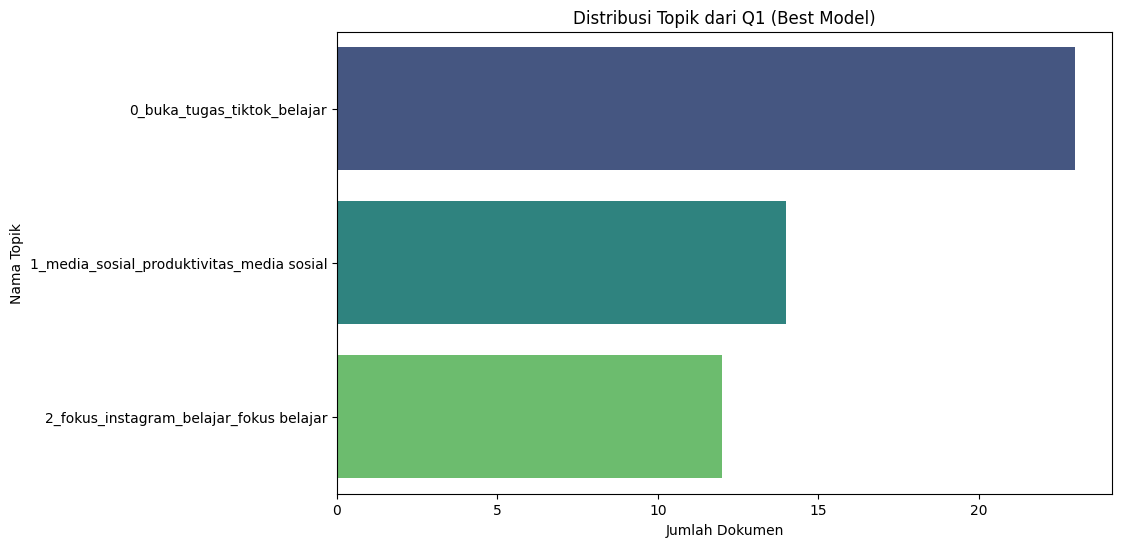

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

topic_counts = result_best['Nama_Topik'].value_counts().reset_index()
topic_counts.columns = ['Nama_Topik', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Nama_Topik', data=topic_counts, palette='viridis')
plt.title('Distribusi Topik dari Q1 (Best Model)')
plt.xlabel('Jumlah Dokumen')
plt.ylabel('Nama Topik')
plt.show()